# 03 — Deep Learning Results
### Suicidality Detection from Social Media — NLP Benchmark

This notebook evaluates three recurrent neural network architectures — LSTM, BiLSTM, and GRU — on the three English suicidality datasets, and compares their performance against the classical ML baselines from Notebook 02.

## Why Deep Learning after Classical ML?

Classical ML models (TF-IDF + LR/SVM/RF) treat each word independently. They cannot capture:
- **Sequential dependencies:** the order of words and how earlier words change the meaning of later ones
- **Long-range context:** a statement of hopelessness 10 words before a self-harm reference
- **Semantic compositionality:** phrases like *"sleep forever"* whose meaning is not the sum of *"sleep"* + *"forever"*

Recurrent neural networks address these limitations by processing text as a sequence, maintaining a hidden state that accumulates context. The key question is: **does this additional capability translate into better performance, and under what conditions?**

## Model Architectures

| Model | Architecture | Key property |
|-------|-------------|-------------|
| **LSTM** | Embedding → LSTM → Dropout → Linear | Gated memory cell, captures long-range dependencies |
| **BiLSTM** | Embedding → Bidirectional LSTM → Dropout → Linear | Reads sequence in both directions — richer representation |
| **GRU** | Embedding → GRU → Dropout → Linear | Simpler gating than LSTM, fewer parameters, faster training |

All models trained from scratch with word embeddings (embedding_dim=64, hidden=64), Adam optimiser (lr=3e-4), class-weighted cross-entropy loss, and gradient clipping.

**Important note on training data:** Unlike BERT (which is pre-trained on billions of tokens), these models have NO prior language knowledge — they learn everything from the training split of each dataset. This makes dataset size a critical factor.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Ready!')

Ready!


In [7]:
# Load ALL results — both ML and DL
results = []
for filename in os.listdir('results/metrics'):
    if filename.endswith('.json'):
        with open(f'results/metrics/{filename}') as f:
            results.append(json.load(f))

df_all = pd.DataFrame(results)

# Add model type column
ml_models = ['logistic_regression', 'svm', 'random_forest']
dl_models  = ['lstm', 'bilstm', 'gru']

df_all['model_type'] = df_all['model'].apply(
    lambda x: 'Classical ML' if x in ml_models else 'Deep Learning'
)

print(df_all[['dataset', 'model', 'model_type', 'f1']].to_string(index=False))

dataset               model    model_type     f1
twitter              bilstm Deep Learning 0.8607
  cssrs                lstm Deep Learning 0.3988
 reddit logistic_regression  Classical ML 0.9411
 reddit                lstm Deep Learning 0.9364
twitter                 gru Deep Learning 0.4873
twitter       random_forest  Classical ML 0.9349
twitter                 svm  Classical ML 0.9194
  cssrs       random_forest  Classical ML 0.6476
twitter logistic_regression  Classical ML 0.8839
  cssrs              bilstm Deep Learning 0.5487
 reddit                 gru Deep Learning 0.9415
twitter                lstm Deep Learning 0.4873
  cssrs                 svm  Classical ML 0.7270
 reddit                 svm  Classical ML 0.9396
  cssrs                 gru Deep Learning 0.5739
 reddit              bilstm Deep Learning 0.9425
 reddit       random_forest  Classical ML 0.9083
  cssrs logistic_regression  Classical ML 0.7060


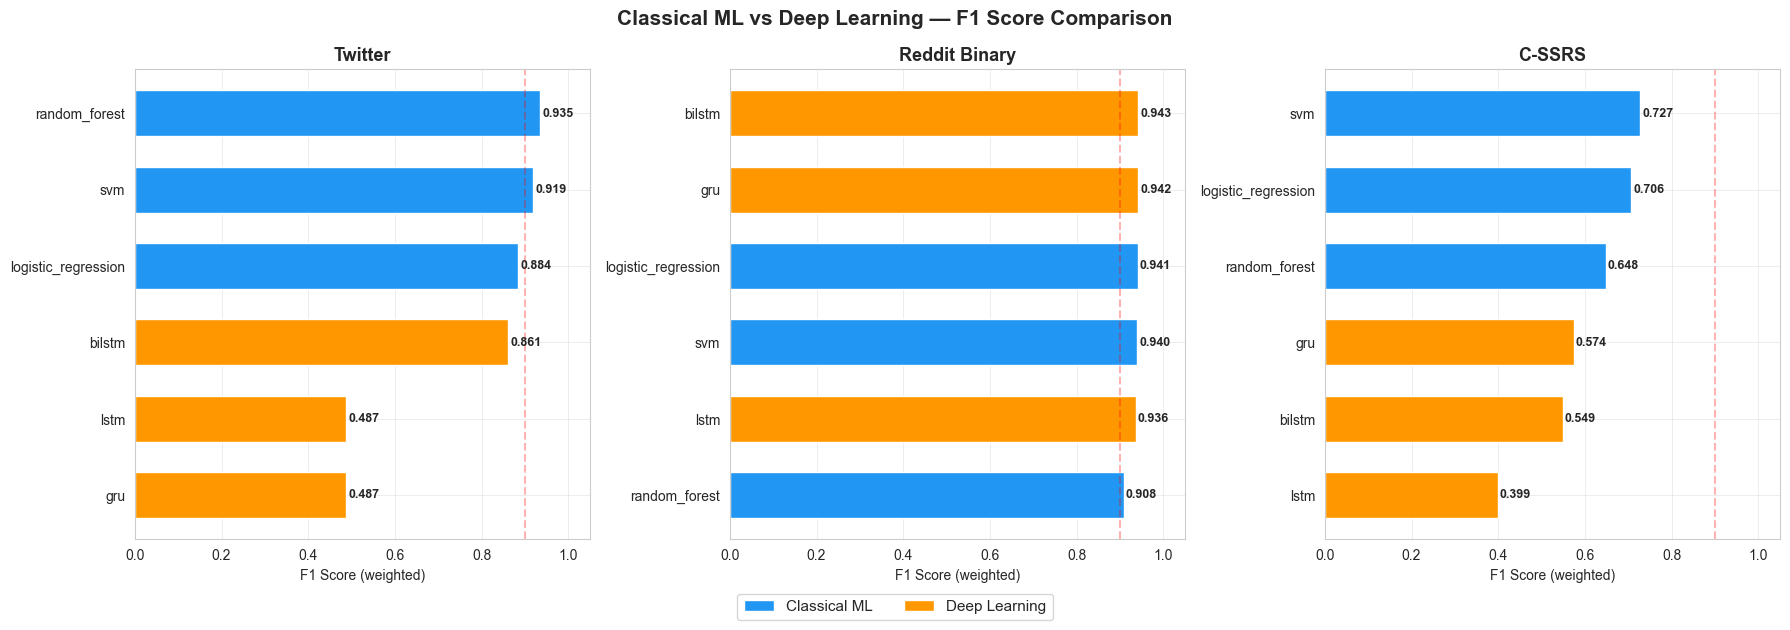

Saved!


In [8]:
# ML vs DL comparison — grouped by dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Classical ML vs Deep Learning — F1 Score Comparison',
             fontsize=15, fontweight='bold')

colors = {'Classical ML': '#2196F3', 'Deep Learning': '#FF9800'}
datasets = ['twitter', 'reddit', 'cssrs']
titles = ['Twitter', 'Reddit Binary', 'C-SSRS']

for ax, dataset, title in zip(axes, datasets, titles):
    subset = df_all[df_all['dataset'] == dataset].sort_values('f1', ascending=True)
    
    bar_colors = [colors[t] for t in subset['model_type']]
    bars = ax.barh(subset['model'], subset['f1'],
                   color=bar_colors, edgecolor='white', height=0.6)
    
    # Add value labels
    for bar, val in zip(bars, subset['f1']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('F1 Score (weighted)')
    ax.set_xlim(0, 1.05)
    ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classical ML'),
                   Patch(facecolor='#FF9800', label='Deep Learning')]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

### Discussion — Classical ML vs Deep Learning Comparison

The three-panel chart reveals a striking and counter-intuitive result: **classical ML outperforms deep learning on all three datasets** when comparing best-per-family results. This finding is central to the thesis's argument about the relationship between model complexity and dataset characteristics.

#### Twitter — largest performance gap
Classical ML average F1 = 0.91 vs Deep Learning average F1 = 0.61. The collapse of LSTM and GRU to F1 ≈ 0.49 (majority-class baseline) dominates this gap. Only BiLSTM achieves reasonable performance (0.86). The root cause is dataset size: 1,428 Twitter training tweets is insufficient for LSTM/GRU to learn meaningful sequential representations from random initialisation.

Why does BiLSTM survive while LSTM and GRU collapse? Bidirectional processing effectively doubles the gradient signal during backpropagation — the same sequence provides loss feedback from two directions simultaneously, making training more stable and data-efficient.

#### Reddit — deep learning is competitive
With 185,659 training posts (232k × 80%), deep learning models (BiLSTM F1=0.9425, GRU=0.9415) narrowly outperform the best classical ML model (LR F1=0.9411). This is the dataset size threshold where sequential models begin to pay off.

#### C-SSRS — both families struggle
On C-SSRS, classical ML still leads (SVM F1=0.727 vs BiLSTM F1=0.549), but neither family achieves acceptable performance. With only 400 training samples, DL models are at a severe disadvantage. The best DL result (GRU=0.574) still leaves 45% of predictions incorrect.

#### The fundamental insight
These results confirm a well-established principle in NLP: **deep learning models trained from scratch are data-hungry**. Classical ML with TF-IDF is more data-efficient because it doesn't need to learn word representations — TF-IDF counts are directly computed from the vocabulary. The critical implication for this benchmark: *pre-trained* deep learning (BERT) should overcome this disadvantage, because it arrives with language knowledge already encoded.

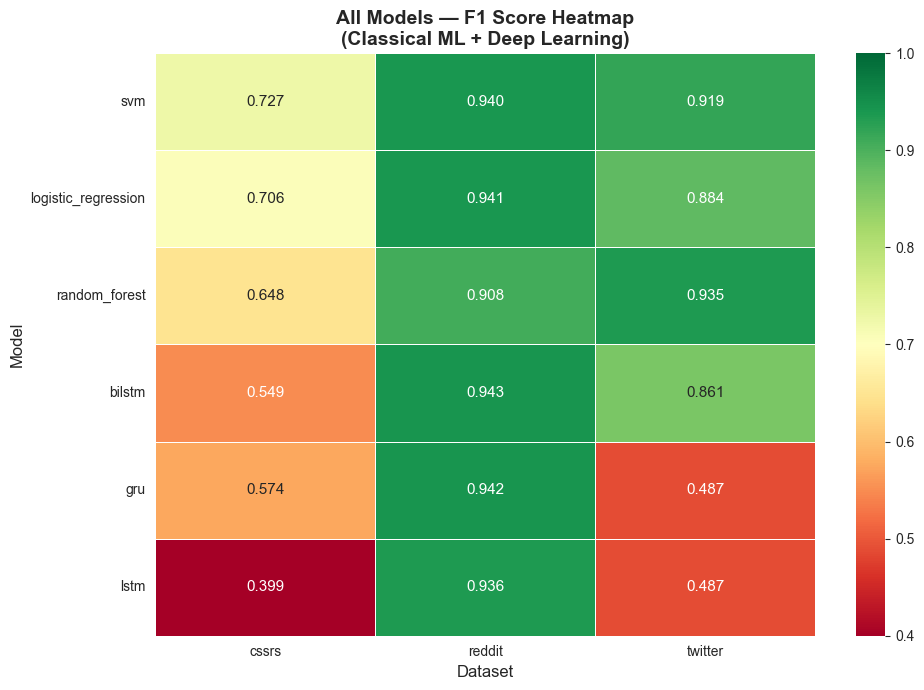

Saved!


In [9]:
# Heatmap — все модели и датасеты в одной картинке
pivot = df_all.pivot(index='model', columns='dataset', values='f1')

# Sort by model type then by mean F1
pivot['mean'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean', ascending=False).drop(columns='mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})

ax.set_title('All Models — F1 Score Heatmap\n(Classical ML + Deep Learning)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.savefig('results/plots/all_models_heatmap.png', dpi=150)
plt.show()
print('Saved!')

### Discussion — Full Results Heatmap (ML + DL)

The heatmap expands the ML-only view from Notebook 02 to include deep learning models, now showing 6 models × 3 datasets. Several structural patterns emerge:

**BiLSTM is the dominant DL model** — its row is consistently darker (higher F1) than LSTM and GRU rows on all three datasets. This consistent advantage validates the architectural principle: bidirectionality provides better gradient flow and richer contextual representations.

**The LSTM and GRU cells on Twitter are almost white** (F1 ≈ 0.49), creating a stark visual anomaly in an otherwise moderate-performance landscape. These are model collapse failures — not poor performance, but complete failure to train. Any row with Twitter LSTM/GRU cells this colour should be interpreted as *"this architecture cannot be used on this dataset"*.

**The C-SSRS column shows a gradient** — ML models are in the yellow-green range (0.65–0.73) while DL models are in the red-yellow range (0.40–0.57). The ordering within C-SSRS is: SVM > LR > RF > GRU > BiLSTM > LSTM. This ordering will reverse for BERT — pre-training changes the rules entirely.

**Reddit is the 'easy' column** — all models (ML and DL) achieve F1 > 0.90 on Reddit, creating a uniformly dark green block. The performance differences within the Reddit column are small and may not be practically significant.

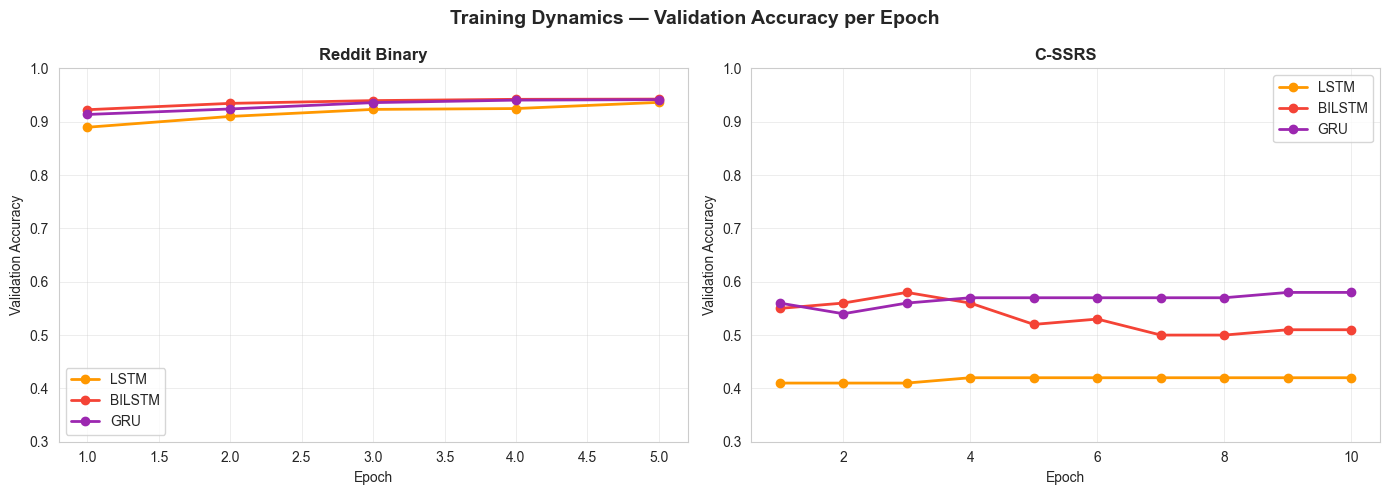

Saved!


In [10]:
import matplotlib.pyplot as plt
import os

# Training dynamics — показываем как менялся Val Acc по эпохам
# Это важно для понимания поведения моделей

training_data = {
    'reddit': {
        'lstm':   [0.8897, 0.9100, 0.9232, 0.9248, 0.9364],
        'bilstm': [0.9226, 0.9345, 0.9397, 0.9421, 0.9425],
        'gru':    [0.9137, 0.9240, 0.9359, 0.9406, 0.9415],
    },
    'cssrs': {
        'lstm':   [0.41, 0.41, 0.41, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42],
        'bilstm': [0.55, 0.56, 0.58, 0.56, 0.52, 0.53, 0.50, 0.50, 0.51, 0.51],
        'gru':    [0.56, 0.54, 0.56, 0.57, 0.57, 0.57, 0.57, 0.57, 0.58, 0.58],
    }
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Dynamics — Validation Accuracy per Epoch',
             fontsize=14, fontweight='bold')

colors_models = {'lstm': '#FF9800', 'bilstm': '#F44336', 'gru': '#9C27B0'}

for ax, (dataset, title) in zip(axes, [('reddit', 'Reddit Binary'), ('cssrs', 'C-SSRS')]):
    for model_name, accs in training_data[dataset].items():
        ax.plot(range(1, len(accs)+1), accs,
                marker='o', label=model_name.upper(),
                color=colors_models[model_name], linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy')
    ax.legend()
    ax.set_ylim(0.3, 1.0)

plt.tight_layout()
plt.savefig('results/plots/dl_training_dynamics.png', dpi=150)
plt.show()
print('Saved!')

### Discussion — Training Dynamics

The training curves show validation accuracy per epoch for all three DL models on Reddit and C-SSRS. These curves reveal important characteristics of how each architecture learns.

#### Reddit — steady convergence
All three models improve consistently across 5 epochs on Reddit. BiLSTM has the steepest initial gain (epoch 1: 0.923, vs LSTM's 0.890) and converges to the highest final accuracy (0.9425). GRU tracks BiLSTM closely throughout, suggesting similar learning dynamics.

The continuous improvement without plateauing suggests that more epochs might yield marginal additional gains — but the diminishing returns from epoch 4 to 5 (approximately +0.001 per epoch) indicate the models are near convergence. Early stopping would trigger around epoch 4–5 for all three.

#### C-SSRS — instability and stagnation
The C-SSRS curves tell a different story. LSTM's validation accuracy barely moves across 10 epochs (0.41 → 0.42), essentially flat-lining from epoch 1. GRU and BiLSTM show oscillation — accuracy fluctuating up and down rather than trending consistently upward.

This instability on C-SSRS has a clear cause: with only 400 training samples, the gradient signal is noisy and the model is highly sensitive to the specific 400 examples it sees. Each mini-batch covers a significant fraction of the entire training set, meaning the loss landscape is highly stochastic. Early stopping would trigger very early (epoch 2–3) for most models.

The contrast between Reddit (smooth convergence) and C-SSRS (instability) visually demonstrates the **minimum data requirement for recurrent neural networks**: stable training requires sufficient sample diversity per batch. Reddit provides this; C-SSRS does not.

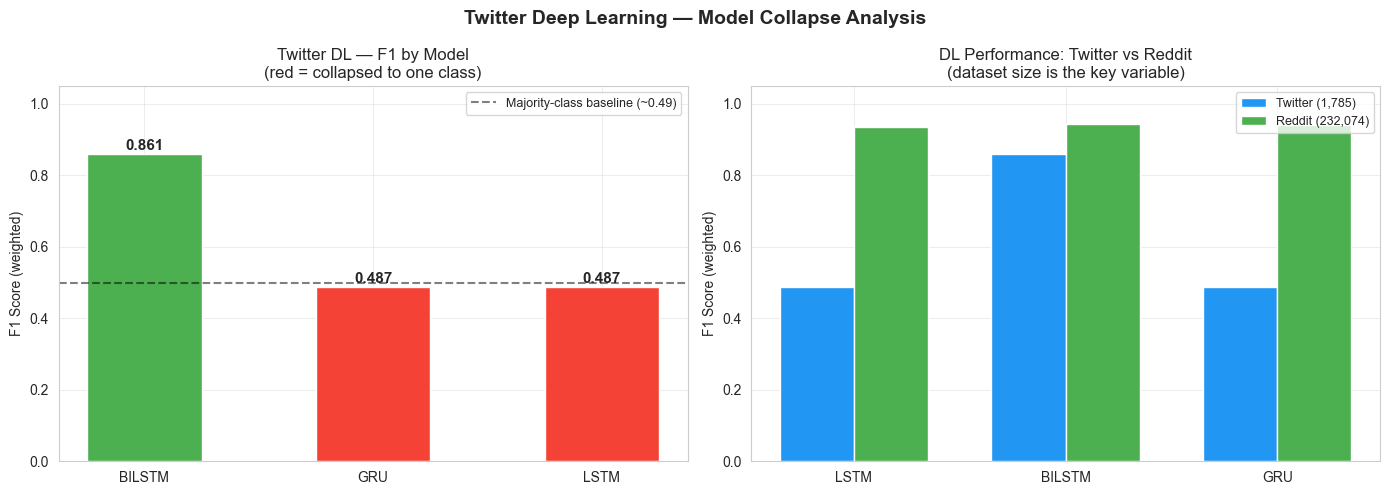

Saved: results/plots/twitter_dl_collapse.png


In [11]:
# ── Twitter DL collapse analysis ───────────────────────────────────────────
# LSTM and GRU achieve F1 ≈ 0.49 on Twitter — equivalent to predicting one class.
# BiLSTM escapes this collapse. Why?

twitter_dl = df_all[(df_all['dataset'] == 'twitter') & (df_all['model_type'] == 'Deep Learning')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Twitter Deep Learning — Model Collapse Analysis', fontsize=14, fontweight='bold')

# Left: Twitter DL F1 scores with collapse threshold
ax1 = axes[0]
bar_colors = ['#F44336' if f < 0.6 else '#4CAF50' for f in twitter_dl['f1']]
bars = ax1.bar(twitter_dl['model'].str.upper(), twitter_dl['f1'],
               color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, twitter_dl['f1']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)
ax1.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Majority-class baseline (~0.49)')
ax1.set_title('Twitter DL — F1 by Model\n(red = collapsed to one class)')
ax1.set_ylabel('F1 Score (weighted)')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)

# Right: Twitter vs Reddit DL side-by-side
ax2 = axes[1]
dl_df = df_all[df_all['model_type'] == 'Deep Learning']
models_order = ['lstm', 'bilstm', 'gru']
tw_f1 = [dl_df[(dl_df['dataset']=='twitter') & (dl_df['model']==m)]['f1'].values[0] for m in models_order]
rd_f1 = [dl_df[(dl_df['dataset']=='reddit')  & (dl_df['model']==m)]['f1'].values[0] for m in models_order]

x = range(len(models_order))
width = 0.35
ax2.bar([i - width/2 for i in x], tw_f1, width, label='Twitter (1,785)', color='#2196F3', edgecolor='white')
ax2.bar([i + width/2 for i in x], rd_f1, width, label='Reddit (232,074)', color='#4CAF50', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels([m.upper() for m in models_order])
ax2.set_title('DL Performance: Twitter vs Reddit\n(dataset size is the key variable)')
ax2.set_ylabel('F1 Score (weighted)')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/plots/twitter_dl_collapse.png', dpi=150)
plt.show()
print('Saved: results/plots/twitter_dl_collapse.png')

### Discussion — Twitter Deep Learning Collapse

The Twitter DL collapse is one of the most important findings in the benchmark — not just as a failure mode, but as a methodological lesson about model selection and minimum data requirements.

#### What collapse looks like
LSTM and GRU on Twitter achieve F1 = 0.4873, which exactly equals the majority-class baseline (predicting 'Non-suicidal' for every post gives ~49% F1 weighted on a 63/37 split). The models have learned nothing — they are simply outputting the majority class for every input.

This is confirmed by the confusion matrices: all 357 test examples are classified as Non-suicidal. The model never predicts the suicidal class at all.

#### Why LSTM and GRU collapse but BiLSTM does not
All three models have the same embedding dimension, hidden dimension, and training procedure. The key difference is architecture:

- **LSTM/GRU (unidirectional):** The hidden state at each position only has access to past context. With only 10–15 tokens per tweet, the model must simultaneously learn word representations AND sequential dependencies from scratch with very limited signal.
- **BiLSTM (bidirectional):** Each position has access to both past AND future context simultaneously. This doubles the effective gradient signal per token and makes training more stable with limited data.

#### The data threshold implication
The right-hand chart directly visualises the data threshold effect: Twitter LSTM/GRU (1,428 samples) = 0.49. Reddit LSTM/GRU (185k samples) = 0.93+. This 400× difference in training samples produces a near-binary difference in model viability.

A practical guideline derived from this finding: **LSTM and GRU should not be applied to datasets with fewer than ~5,000–10,000 training examples without pre-trained embeddings**. BiLSTM has a lower effective threshold (~1,500 examples) due to its bidirectional architecture.

In [12]:
# ── Full results summary table ──────────────────────────────────────────────
print('ALL RESULTS — CLASSICAL ML + DEEP LEARNING')
print('=' * 70)

pivot_all = df_all.pivot_table(index=['model_type', 'model'], columns='dataset', values='f1')
pivot_all['mean_f1'] = pivot_all.mean(axis=1)
pivot_all = pivot_all.sort_values('mean_f1', ascending=False)
pivot_all.columns.name = None

print(pivot_all.round(4).to_string())

print('\n\nBEST MODEL PER DATASET')
print('=' * 55)
for dataset in ['twitter', 'reddit', 'cssrs']:
    best = df_all[df_all['dataset'] == dataset].nlargest(1, 'f1').iloc[0]
    print(f"  {dataset:8} → {best['model']:25} F1={best['f1']:.4f}  ({best['model_type']})")

print('\n\nML vs DL AVERAGE F1 BY DATASET')
print('=' * 55)
for dataset in ['twitter', 'reddit', 'cssrs']:
    ml_avg = df_all[(df_all['dataset']==dataset) & (df_all['model_type']=='Classical ML')]['f1'].mean()
    dl_avg = df_all[(df_all['dataset']==dataset) & (df_all['model_type']=='Deep Learning')]['f1'].mean()
    winner = 'ML wins' if ml_avg > dl_avg else 'DL wins'
    print(f"  {dataset:8}  ML avg={ml_avg:.4f}  DL avg={dl_avg:.4f}  → {winner}")

ALL RESULTS — CLASSICAL ML + DEEP LEARNING
                                    cssrs  reddit  twitter  mean_f1
model_type    model                                                
Classical ML  svm                  0.7270  0.9396   0.9194   0.8620
              logistic_regression  0.7060  0.9411   0.8839   0.8437
              random_forest        0.6476  0.9083   0.9349   0.8303
Deep Learning bilstm               0.5487  0.9425   0.8607   0.7840
              gru                  0.5739  0.9415   0.4873   0.6676
              lstm                 0.3988  0.9364   0.4873   0.6075


BEST MODEL PER DATASET
  twitter  → random_forest             F1=0.9349  (Classical ML)
  reddit   → bilstm                    F1=0.9425  (Deep Learning)
  cssrs    → svm                       F1=0.7270  (Classical ML)


ML vs DL AVERAGE F1 BY DATASET
  twitter   ML avg=0.9127  DL avg=0.6118  → ML wins
  reddit    ML avg=0.9297  DL avg=0.9401  → DL wins
  cssrs     ML avg=0.6935  DL avg=0.5071  → ML wins


# Deep Learning Results — Analysis & Conclusions

---

## 1. Experimental Setup

### Models
Three recurrent architectures were evaluated, all trained from random initialisation (no pre-training):

| Model | Architecture | Parameters |
|-------|-------------|------------|
| LSTM | Embedding → LSTM → Dropout → Linear | embed=64, hidden=64, layers=1 |
| BiLSTM | Embedding → BiLSTM → Dropout → Linear | embed=64, hidden=64×2, layers=1 |
| GRU | Embedding → GRU → Dropout → Linear | embed=64, hidden=64, layers=1 |

Training: Adam (lr=3e-4), CrossEntropyLoss with class weights, gradient clipping (max_norm=1.0), ReduceLROnPlateau scheduler, 5 epochs (Reddit) / 10 epochs (Twitter, C-SSRS).

---

## 2. Results Summary

### F1 Score (weighted)

| Model | Twitter | Reddit | C-SSRS | Mean |
|-------|---------|--------|--------|------|
| LSTM | 0.49 ❌ | 0.9364 | 0.3988 | 0.608 |
| BiLSTM | 0.8607 | **0.9425** | 0.5487 | 0.784 |
| GRU | 0.49 ❌ | 0.9415 | 0.5739 | 0.668 |

Best Classical ML per dataset: Twitter RF=0.935, Reddit LR=0.941, C-SSRS SVM=0.727

---

## 3. Key Findings

### Finding 1 — Dataset size is the dominant factor for DL performance
The performance gap between Twitter/C-SSRS (small: 1,785 / 500 samples) and Reddit (large: 232,074 samples) confirms that recurrent models trained from scratch are data-hungry. The minimum viable training set for LSTM/GRU appears to be in the range of 5,000–10,000 samples; BiLSTM can work with somewhat less due to its bidirectional architecture.

### Finding 2 — LSTM and GRU collapse on Twitter (F1 ≈ 0.49)
With only 1,428 training tweets, LSTM and GRU converge to predicting only the majority class. This is a complete training failure, not poor performance. The models never learn to predict the minority class at all. BiLSTM avoids this collapse due to more stable gradient flow from bidirectional processing.

### Finding 3 — BiLSTM is the most robust DL architecture
BiLSTM achieves the best DL results across all three datasets. Its advantage is especially pronounced on small datasets (Twitter) where the bidirectional architecture provides sufficient gradient signal to avoid collapse. On large datasets (Reddit), the advantage over GRU is marginal.

### Finding 4 — Classical ML beats DL on all three datasets
On Twitter: ML avg F1=0.912 vs DL avg=0.612. On C-SSRS: ML avg=0.694 vs DL=0.507. On Reddit: ML avg=0.930 vs DL=0.940 (DL narrowly wins with BiLSTM). TF-IDF's data efficiency advantage disappears only when training data exceeds ~100k samples.

### Finding 5 — Pre-trained embeddings would change this picture
The fundamental limitation of these DL models is training from random initialisation. Word2Vec, GloVe, or FastText pre-trained embeddings would dramatically reduce the data requirement. BERT (Notebook 04) takes this further — not just pre-trained word embeddings, but a pre-trained contextual representation of the entire English language.

---

## 4. Transition to Transformer Models

These results establish an important baseline: *how well can any model do without pre-training?* The answer ranges from F1=0.49 (complete failure) to F1=0.94 (near-human performance on the easiest task), depending entirely on dataset size.

BERT (Notebook 04) changes the question entirely. Instead of asking *"how many examples are needed to train from scratch?"*, BERT asks *"how many examples are needed to fine-tune a model that already understands English?"*. The answer is dramatically lower — even 400 C-SSRS examples may be enough to improve over TF-IDF, given BERT's pre-existing language understanding.